---
title: Analysing snow cover in the Alps using Sentinel-2
subtitle: Learn how to use the EOPF Zarr data to analyse snow cover dynamics in the Alps with Sentinel-2 imagery.
authors:
  - name: Michele Claus
    orcid: 0000-0003-3680-381X
    github: clausmichele
    affiliations:
      - id: Eurac Research
        institution: Eurac Research
        ror: 01xt1w755
  - name: Juraj Zvolenský
    orcid: 0009-0000-9185-7955
    github: jzvolensky
    affiliations:
      - id: Eurac Research
        institution: Eurac Research
        ror: 01xt1w755
  - name: Peter Zellner
    orcid: 0000-0002-3394-9664
    github: przell
    affiliations:
      - id: DLR
        institution: German Aerospace Center
        ror: 04bwf3e34
date: 2025-12-03
thumbnail: https://raw.githubusercontent.com/EOPF-Sample-Service/eopf-sample-notebooks/refs/heads/main/notebooks/static/ESA_logo_2020_Deep.png
keywords: ["earth observation", "remote sensing", "sentinel-2", "snow cover", "alps", "zarr", "eopf"]
tags: ["sentinel-2", "land", "stac"]
releaseDate: 2025-12-03
datePublished: 2025-12-03
dateModified: 2025-12-03
github: https://github.com/EOPF-Sample-Service/eopf-sample-notebooks
license: Apache-2.0
---

```{image} ../static/EOPF-on-bright-baseline.png
:alt: ESA EOPF Zarr Logo
:width: 250px
:align: center
```

## Table of contents

- [Introduction](#Introduction_CC_SNOW)
- [Setup](#Setup_CC_SNOW)
- [Define Region of Interest](#Define_Region_of_Interest_CC_SNOW)
- [Search for data and create a datacube](#Search_for_data_and_create_a_datacube_CC_SNOW)
- [Crop catchment area](#Crop-catchment-area-CC_SNOW)
- [Visualize area of interest](Visualize_area_of_interest_CC_SNOW)
- [Calculate Normalized Difference Snow Index (NDSI)](#Calculate_Normalized_Difference_Snow_Index_CC_SNOW)
- [Create snow map](#Create_snow_map_CC_SNOW)
- [Create and apply cloud mask](#Create_and_apply_cloud_mask_CC_SNOW)
- [Visualize timeseries step ](#Visualize_timeseries_step_CC_SNOW)
- [Calculate catchment statistics](#Calculate_catchment_statistics_CC_SNOW)
- [Plot cloud percentage time series](plot_cloud_percentage_time_series_CC_SNOW)
- [Plot unfiltered snow percentage](plot_unfiltered_snow_percentage_CC_SNOW)
- [Plot cloud filtered snow percentage](plot_cloud_filtered_snow_percentage_CC_SNOW)
- [Compare to discharge data](#Compare_to_discharge_data_CC_SNOW)

(Introduction_CC_SNOW)=
## Introduction

This notebook demonstrates the whole workflow of accessing and analysing Sentinel-2 data from the EOPF Zarr data repository to study snow cover dynamics in the Alps.

We are going to follow these steps in our analysis:

Load satellite collections
Specify the spatial, temporal extents and the features we are interested in
Process the satellite data to retrieve snow cover information
aggregate information in data cubes
Visualize and analyse the results

This example comes from the [Cubes and Clouds MOOC available on EO College](https://eo-college.org/courses/cubes-and-clouds/), developed by Eurac Research. The original notebook can be found [here](https://github.com/EO-College/cubes-and-clouds/blob/main/lectures/3.1_data_processing/exercises/_alternatives/31_data_processing_stac.ipynb).


:::{hint} Overview
**Questions**
- How to access Sentinel-2 data from EOPF Zarr?
- How to visualise snow cover in the Alps using Sentinel-2 imagery?
- How to work with datacubes in Zarr format?

**Objectives**
- Access Sentinel-2 EOPF Zarr data
- Preprocess Sentinel-2 imagery
- Visualize results

(Setup_CC_SNOW)=
## Setup
Start importing the necessary libraries

In [1]:
from datetime import datetime
import xarray as xr
import dask
from pyproj import Transformer
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
import pystac_client

(Define_Region_of_Interest_CC_SNOW)=

## Define Region of Interest

We use the catchment boundary to define our area of interest.

In [2]:
catchment_outline = gpd.read_file("./geojson/catchment_outline_cc_31.geojson")
bbox = list(catchment_outline.total_bounds)  # minx, miny, maxx, maxy
bbox

[11.020833333333357,
 46.653599378797765,
 11.366666666666694,
 46.954166666666694]

(Search_for_data_and_create_a_datacube_CC_SNOW)=
## Search for data and create a datacube

In [3]:
catalog = pystac_client.Client.open("https://stac.core.eopf.eodc.eu")
search = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=bbox,
    datetime="2018-02-01/2018-06-30",
    query={"eo:cloud_cover": {"lt": 75}},
)

items = list(search.items())
print(f"{len(items)} STAC Items found!")

59 STAC Items found!


In [4]:
def reproject_bbox(bbox, src_crs="EPSG:4326", dst_crs="EPSG:32632"):
    transformer = Transformer.from_crs(src_crs, dst_crs, always_xy=True)
    xmin, ymin = transformer.transform(bbox[0], bbox[1])
    xmax, ymax = transformer.transform(bbox[2], bbox[3])
    return [xmin, ymin, xmax, ymax]


def load_tile(item, bbox_ll):
    href = item.assets["product"].href
    ds = xr.open_datatree(href, engine="zarr", chunks={}, mask_and_scale=True)

    dst_crs = item.properties.get("proj:code")
    if dst_crs is None:
        raise ValueError(f"No proj:code in item {item.id}")

    utm_bbox = reproject_bbox(bbox_ll, dst_crs=dst_crs)

    ds_ref = ds["measurements"]["reflectance"]["r20m"].to_dataset()[
        ["b02", "b03", "b04", "b11"]
    ]
    ds_scl = ds["conditions"]["mask"]["l2a_classification"]["r20m"].to_dataset()
    ds_out = (
        xr.merge([ds_ref, ds_scl])
        .sel(x=slice(utm_bbox[0], utm_bbox[2]), y=slice(utm_bbox[3], utm_bbox[1]))
        .expand_dims(time=[item.datetime])
    )
    return ds_out


delayed_results = [dask.delayed(load_tile)(item, bbox) for item in items]
results = dask.compute(*delayed_results)

# Get CRS from STAC item
crs = items[0].properties.get("proj:code")
datacube = xr.concat(results, dim="time")
datacube = datacube.assign_coords(time=pd.to_datetime(datacube.time.values)).sortby(
    "time"
)
datacube = datacube.groupby(datacube.time.dt.floor("D")).max()
datacube = datacube.rename(floor="time").sortby("time")

datacube = datacube.rio.write_crs(crs, inplace=True)
datacube

<xarray.Dataset> Size: 3GB
Dimensions:      (time: 40, y: 1706, x: 1273)
Coordinates:
  * x            (x) float32 5kB 6.546e+05 6.546e+05 ... 6.8e+05 6.801e+05
  * y            (y) float32 7kB 5.169e+06 5.169e+06 ... 5.203e+06 5.203e+06
  * time         (time) datetime64[ns] 320B 2018-02-03 2018-02-06 ... 2018-06-26
    spatial_ref  int64 8B 0
Data variables:
    b02          (time, y, x) float64 695MB dask.array<chunksize=(1, 627, 14), meta=np.ndarray>
    b03          (time, y, x) float64 695MB dask.array<chunksize=(1, 627, 14), meta=np.ndarray>
    b04          (time, y, x) float64 695MB dask.array<chunksize=(1, 627, 14), meta=np.ndarray>
    b11          (time, y, x) float64 695MB dask.array<chunksize=(1, 627, 14), meta=np.ndarray>
    scl          (time, y, x) float64 695MB dask.array<chunksize=(1, 627, 14), meta=np.ndarray>

(Crop-catchment-area-CC_SNOW)=
## Crop catchment area

In [5]:
datacube = datacube.sortby("y", ascending=False)
datacube = datacube.rio.write_transform()
catchment_outline = catchment_outline.to_crs(datacube.rio.crs)

datacube = datacube.rio.clip(
    catchment_outline.geometry.values,
    catchment_outline.crs,
    all_touched=True,
    drop=True,
)
no_data_mask = ~np.isnan(datacube.b02)
datacube

<xarray.Dataset> Size: 3GB
Dimensions:      (x: 1273, y: 1672, time: 40)
Coordinates:
  * x            (x) float32 5kB 6.546e+05 6.546e+05 ... 6.8e+05 6.801e+05
  * y            (y) float32 7kB 5.202e+06 5.202e+06 ... 5.169e+06 5.169e+06
  * time         (time) datetime64[ns] 320B 2018-02-03 2018-02-06 ... 2018-06-26
    spatial_ref  int64 8B 0
Data variables:
    b02          (time, y, x) float64 681MB dask.array<chunksize=(1, 405, 14), meta=np.ndarray>
    b03          (time, y, x) float64 681MB dask.array<chunksize=(1, 405, 14), meta=np.ndarray>
    b04          (time, y, x) float64 681MB dask.array<chunksize=(1, 405, 14), meta=np.ndarray>
    b11          (time, y, x) float64 681MB dask.array<chunksize=(1, 405, 14), meta=np.ndarray>
    scl          (time, y, x) float64 681MB dask.array<chunksize=(1, 405, 14), meta=np.ndarray>

(Visualize_area_of_interest_CC_SNOW)=
## Visualize area of interest

/opt/conda/lib/python3.12/site-packages/dask/array/reductions.py:325: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)


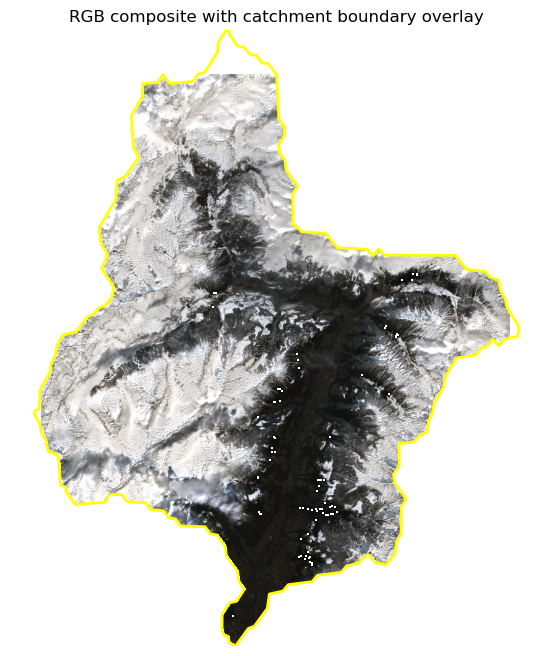

In [6]:
datacube_sample = datacube.isel(time=15)
rgb = datacube_sample[["b04", "b03", "b02"]].to_dataarray(dim="band")
rgb = rgb.assign_coords(band=["red", "green", "blue"])

vmin = float(rgb.min())
vmax = float(rgb.quantile(0.95))
rgb_scaled = (rgb - vmin) / (vmax - vmin)
rgb_scaled = rgb_scaled.clip(0, 1)

rgb_img = rgb_scaled.transpose("y", "x", "band").values

rgb_img = np.ma.masked_invalid(rgb_img)

x = datacube_sample.x.values
y = datacube_sample.y.values

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(rgb_img, extent=[x.min(), x.max(), y.min(), y.max()])

catchment_outline.boundary.plot(ax=ax, edgecolor="yellow", linewidth=2)
ax.set_title("RGB composite with catchment boundary overlay")
ax.axis("off")
plt.show()

(Calculate_Normalized_Difference_Snow_Index_CC_SNOW)=
## Calculate Normalized Difference Snow Index (NDSI)

The Normalized Difference Snow Index (NDSI) is computed as:

$$ NDSI = \frac {GREEN - SWIR} {GREEN +SWIR} $$

In [7]:
ndsi = (datacube["b03"] - datacube["b11"]) / (datacube["b03"] + datacube["b11"])
ndsi = ndsi.rename("ndsi")
ndsi

<xarray.DataArray 'ndsi' (time: 40, y: 1672, x: 1273)> Size: 681MB
dask.array<truediv, shape=(40, 1672, 1273), dtype=float64, chunksize=(1, 426, 915), chunktype=numpy.ndarray>
Coordinates:
  * x            (x) float32 5kB 6.546e+05 6.546e+05 ... 6.8e+05 6.801e+05
  * y            (y) float32 7kB 5.202e+06 5.202e+06 ... 5.169e+06 5.169e+06
  * time         (time) datetime64[ns] 320B 2018-02-03 2018-02-06 ... 2018-06-26
    spatial_ref  int64 8B 0

(Create_snow_map_CC_SNOW)=
## Create snow map

To create a binary snow map, we apply a threshold to the NDSI values. Pixels with NDSI values greater than 0.4 are classified as snow-covered (1), while those with NDSI values less than or equal to 0.4 are classified as non-snow-covered (0).

In [8]:
ndsi_mask = ndsi > 0.42
snowmap = ndsi_mask.rename("snow_map").where(no_data_mask)
snowmap

<xarray.DataArray 'snow_map' (time: 40, y: 1672, x: 1273)> Size: 681MB
dask.array<where, shape=(40, 1672, 1273), dtype=float64, chunksize=(1, 426, 915), chunktype=numpy.ndarray>
Coordinates:
  * x            (x) float32 5kB 6.546e+05 6.546e+05 ... 6.8e+05 6.801e+05
  * y            (y) float32 7kB 5.202e+06 5.202e+06 ... 5.169e+06 5.169e+06
  * time         (time) datetime64[ns] 320B 2018-02-03 2018-02-06 ... 2018-06-26
    spatial_ref  int64 8B 0

(Create_and_apply_cloud_mask_CC_SNOW)=
## Create and apply cloud mask

Using the SCL band from Sentinel-2, we create a cloud mask to filter out cloudy pixels from our snow map.

In [9]:
cloud_mask = datacube["scl"].isin([3, 8, 9])
snowmap_cloudfree = snowmap.where(~cloud_mask, other=2)
snowmap_cloudfree

<xarray.DataArray 'snow_map' (time: 40, y: 1672, x: 1273)> Size: 681MB
dask.array<where, shape=(40, 1672, 1273), dtype=float64, chunksize=(1, 426, 915), chunktype=numpy.ndarray>
Coordinates:
  * x            (x) float32 5kB 6.546e+05 6.546e+05 ... 6.8e+05 6.801e+05
  * y            (y) float32 7kB 5.202e+06 5.202e+06 ... 5.169e+06 5.169e+06
  * time         (time) datetime64[ns] 320B 2018-02-03 2018-02-06 ... 2018-06-26
    spatial_ref  int64 8B 0

(Visualize_timeseries_step_CC_SNOW)=
## Visualize timeseries step 

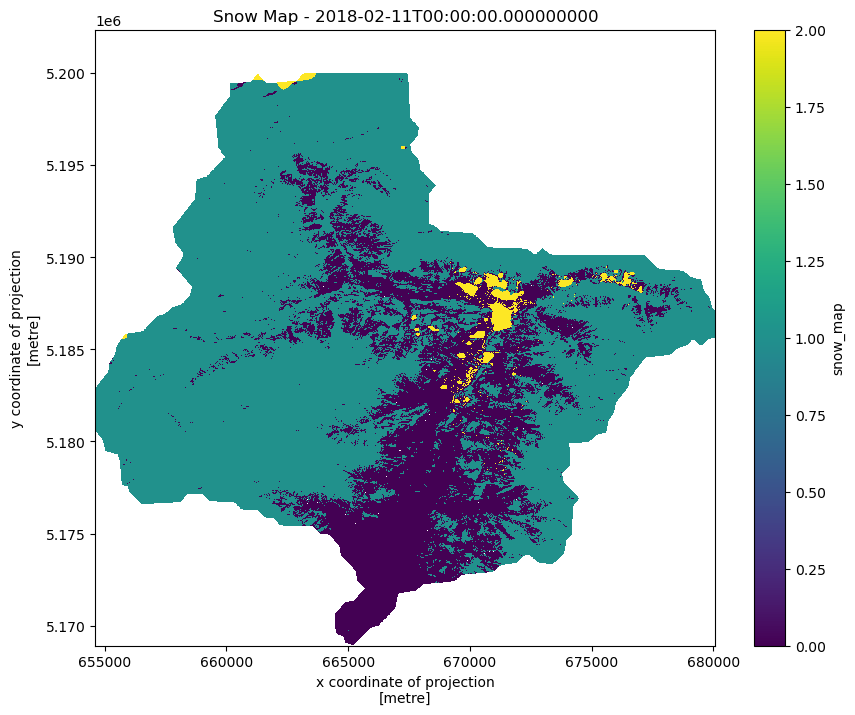

In [10]:
snowmap_1d = snowmap_cloudfree.sel(time=slice("2018-02-10", "2018-02-12"))
fig, ax = plt.subplots(figsize=(10, 8))
snowmap_1d.isel(time=0).plot(ax=ax, cmap="viridis")
ax.set_title(f"Snow Map - {snowmap_1d.time.values[0]}")
plt.show()

(Calculate_catchment_statistics_CC_SNOW)=
## Calculate catchment statistics

We calculate the cloud percentage for the catchment for each timestep. We use this information to filter the timeseries. All timesteps that have a cloud coverage of over 25% will be discarded.

Ultimately we are interested in the snow covered area (SCA) within the catchment. We count all snow covered pixels within the catchment for each time step. Multiplied by the pixel size that would be the snow covered area. Divided the pixel count by the total number of pixels in the catchment is the percentage of pixels covered with snow. We will use this number.


In [11]:
snow_pixels = (snowmap_cloudfree == 1).where(no_data_mask)
cloud_pixels = cloud_mask.where(no_data_mask)
valid_pixels = (snowmap_cloudfree >= 0).where(no_data_mask)

pixel_maps = xr.Dataset(
    {
        "snow_pixels": snow_pixels,
        "cloud_pixels": cloud_pixels,
        "valid_pixels": valid_pixels,
    }
)

In [12]:
catchment_stats = pixel_maps.sum(dim=["x", "y"])

print("Catchment statistics over time:")
print(catchment_stats)

total_pixels = catchment_stats["valid_pixels"]
snow_percentage = catchment_stats["snow_pixels"] / total_pixels * 100
cloud_percentage = catchment_stats["cloud_pixels"] / total_pixels * 100

catchment_stats = catchment_stats.assign(
    snow_percentage=snow_percentage, cloud_percentage=cloud_percentage
).compute()

Catchment statistics over time:
<xarray.Dataset> Size: 1kB
Dimensions:       (time: 40)
Coordinates:
  * time          (time) datetime64[ns] 320B 2018-02-03 ... 2018-06-26
    spatial_ref   int64 8B 0
Data variables:
    snow_pixels   (time) float64 320B dask.array<chunksize=(1,), meta=np.ndarray>
    cloud_pixels  (time) float64 320B dask.array<chunksize=(1,), meta=np.ndarray>
    valid_pixels  (time) float64 320B dask.array<chunksize=(1,), meta=np.ndarray>


/opt/conda/lib/python3.12/site-packages/dask/_task_spec.py:759: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)
/opt/conda/lib/python3.12/site-packages/dask/_task_spec.py:759: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)
/opt/conda/lib/python3.12/site-packages/dask/_task_spec.py:759: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)
/opt/conda/lib/python3.12/site-packages/dask/_task_spec.py:759: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)
/opt/conda/lib/python3.12/site-packages/dask/_task_spec.py:759: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)
/opt/conda/lib/python3.12/site-packages/dask/_task_spec.py:759: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)
/opt/conda/lib/python3.12/site-packages/dask/_task_spec.py:759: RuntimeWarning: divide by zero encou

In [13]:
cloud_threshold = 25

cloud_percent = catchment_stats["cloud_percentage"]

valid_mask = cloud_percent <= cloud_threshold

valid_timesteps = catchment_stats.where(valid_mask, drop=True)

snowmap_filtered = snowmap_cloudfree.where(valid_mask, drop=True)

print("Original timesteps:", len(catchment_stats.time))
print(f"Timesteps with <{cloud_threshold}% clouds:", len(valid_timesteps.time))

Original timesteps: 40
Timesteps with <25% clouds: 22


(plot_cloud_percentage_time_series_CC_SNOW)=
## Plot cloud percentage time series

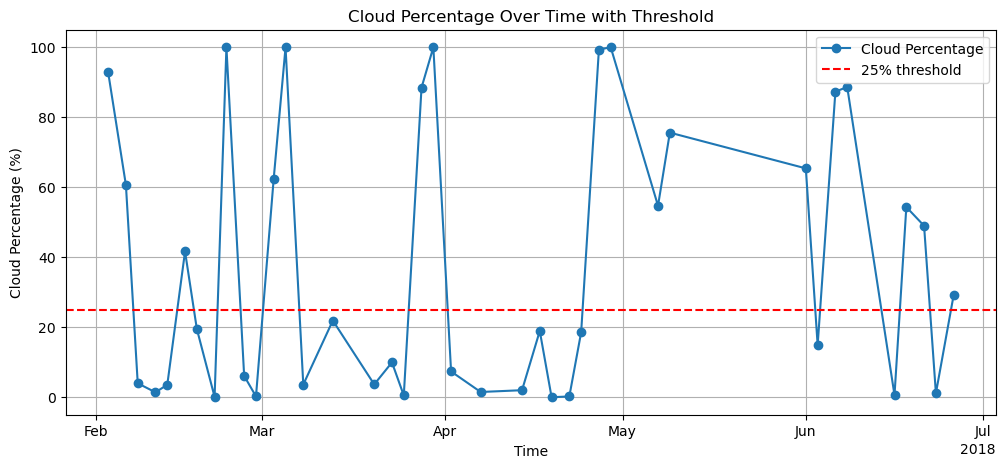

In [14]:
plt.figure(figsize=(12, 5))

cloud_percent = cloud_percent.assign_coords(
    time=pd.to_datetime(cloud_percent.time.astype("int64"))
)

cloud_percent.plot(marker="o", label="Cloud Percentage")

plt.axhline(y=25, color="r", linestyle="--", label="25% threshold")

plt.title("Cloud Percentage Over Time with Threshold")
plt.ylabel("Cloud Percentage (%)")
plt.xlabel("Time")
plt.legend()
plt.grid(True)

plt.show()

(plot_unfiltered_snow_percentage_CC_SNOW)=
## Plot unfiltered snow percentage

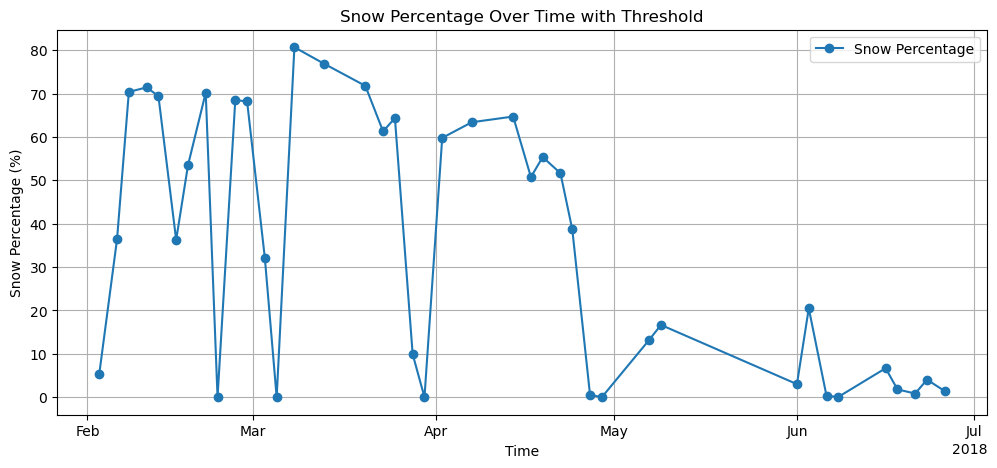

In [15]:
snow_percentage = catchment_stats["snow_percentage"]

plt.figure(figsize=(12, 5))

snow_percentage = snow_percentage.assign_coords(
    time=pd.to_datetime(snow_percentage.time.astype("int64"))
)

snow_percentage.plot(marker="o", label="Snow Percentage")

plt.title("Snow Percentage Over Time with Threshold")
plt.ylabel("Snow Percentage (%)")
plt.xlabel("Time")
plt.legend()
plt.grid(True)

plt.show()

(plot_cloud_filtered_snow_percentage_CC_SNOW)=
## Plot cloud filtered snow percentage

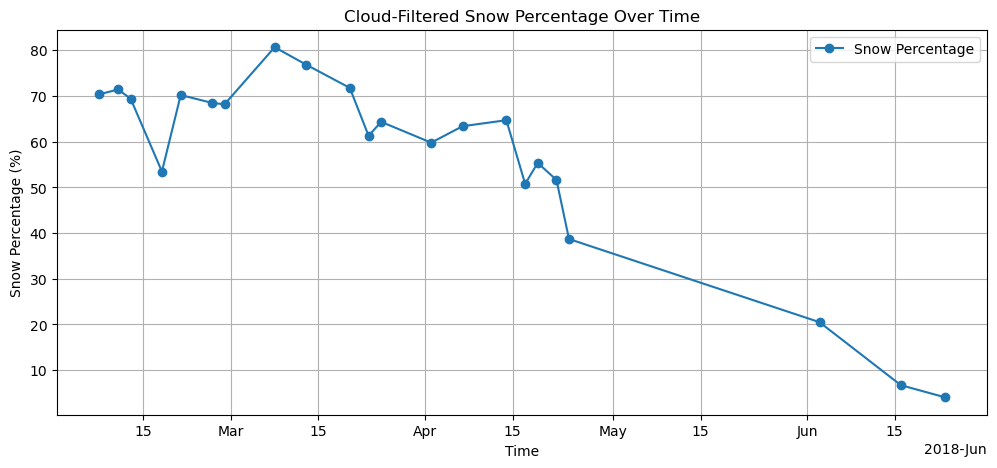

In [16]:
filtered_snow_percentage = snow_percentage.where(valid_mask, drop=True)

filtered_snow_percentage = filtered_snow_percentage.assign_coords(
    time=pd.to_datetime(filtered_snow_percentage.time.astype("int64"))
)

plt.figure(figsize=(12, 5))

filtered_snow_percentage.plot(marker="o", label="Snow Percentage")

plt.title("Cloud-Filtered Snow Percentage Over Time")
plt.ylabel("Snow Percentage (%)")
plt.xlabel("Time")
plt.legend()
plt.grid(True)
plt.show()

(Compare_to_discharge_data_CC_SNOW)=
## Compare to discharge data

In [17]:
discharge_ds = pd.read_csv(
    "./csv/ADO_DSC_ITH1_0025_CC_31.csv", sep=",", index_col="Time", parse_dates=True
)
discharge_ds.head()

,discharge_m3_s
Time,
1994-01-01 01:00:00,4.03
1994-01-02 01:00:00,3.84
1994-01-03 01:00:00,3.74
1994-01-04 01:00:00,3.89
1994-01-05 01:00:00,3.80


Compare the discharge data to the snow covered area.

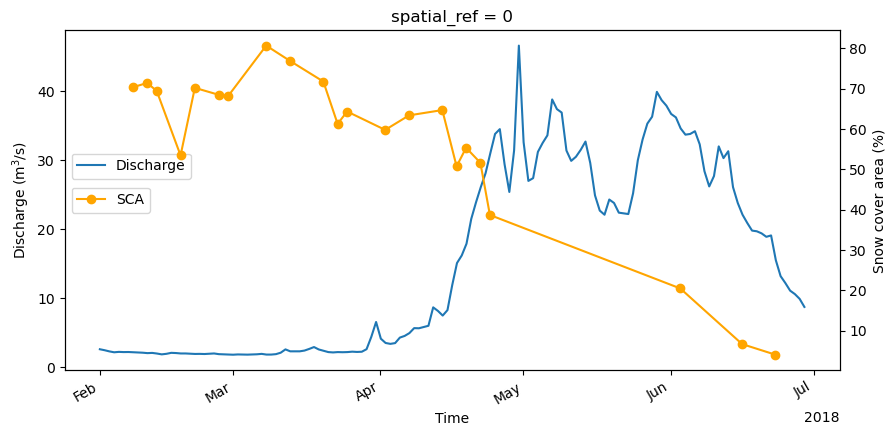

In [18]:
start_date = datetime(2018, 2, 1)
end_date = datetime(2018, 6, 30)

snow_percent = filtered_snow_percentage.sel(time=slice(start_date, end_date))
discharge_ds = discharge_ds.loc[start_date:end_date]

fig, ax0 = plt.subplots(1, figsize=(10, 5), sharey=True)
ax1 = ax0.twinx()

discharge_ds.discharge_m3_s.plot(
    label="Discharge", ylabel="Discharge (m$^3$/s)", ax=ax0
)
snow_percent.plot(marker="o", ax=ax1, color="orange")

ax0.legend(loc="center left", bbox_to_anchor=(0, 0.6))
ax1.set_ylabel("Snow cover area (%)")
ax1.legend(loc="center left", bbox_to_anchor=(0, 0.5), labels=["SCA"])

plt.show()

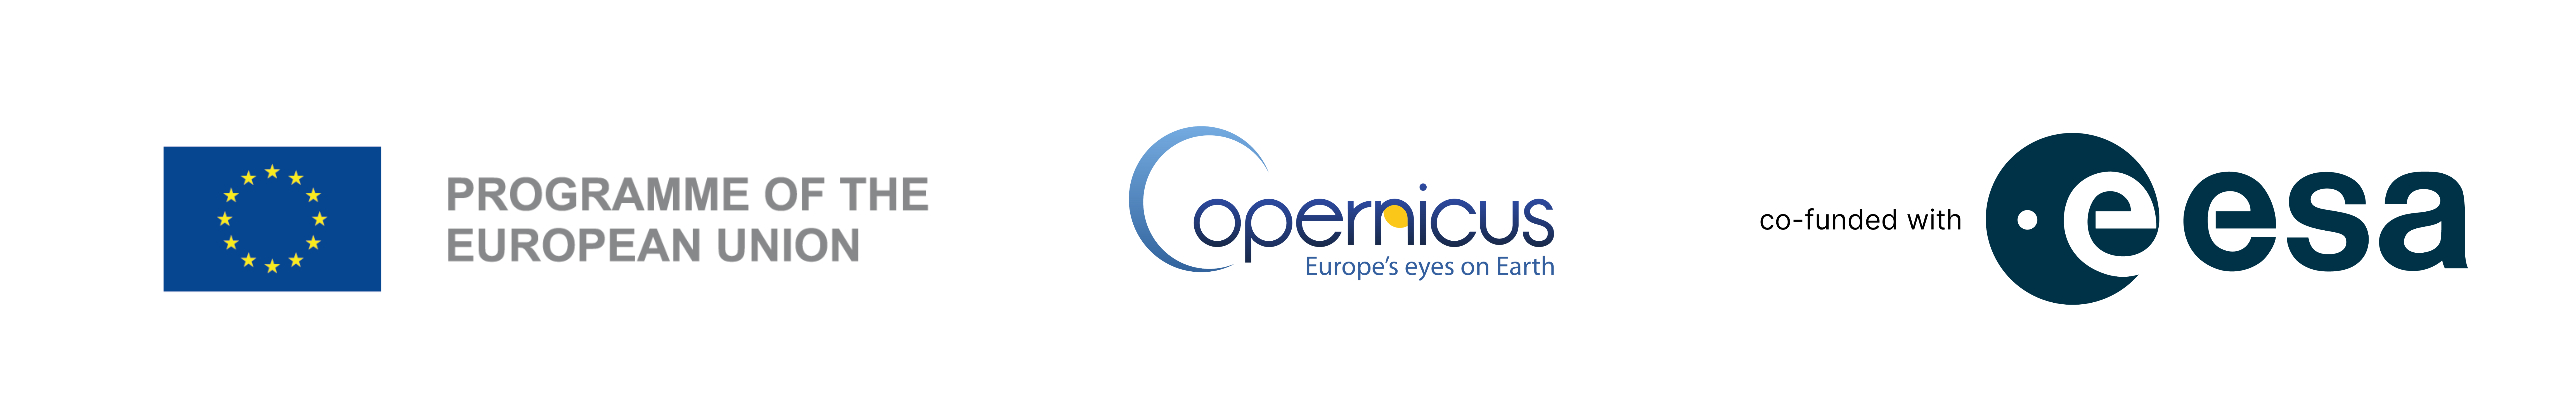